In [1]:
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    desc_add="clean",
)

config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep.yml")


EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping


In [3]:
from mreyemove.analysis.glm.atlas import fetch_atlas

atlas = fetch_atlas("schaefer500")

schaefer_groups = {}
for label in atlas.labels:
    if label in ("Background", "???"):
        continue
    # Split the label, format: "LH_Vis_1"
    parts = label.split('_')
    if len(parts) >= 3:
        hemi, network, idx = parts[1], parts[2], parts[3]
        schaefer_groups[label] = network
    else:
        schaefer_groups[label] = None  # fallback
schaefer_order = ['Vis', 'Cont', 'DorsAttn', 'Default',  'SomMot', 'SalVentAttn',  'Limbic']

[fetch_atlas_schaefer_2018] Dataset found in /Users/zach/nilearn_data/schaefer_2018


In [97]:
schaefer_groups

{'7Networks_LH_Vis_1': 'Vis',
 '7Networks_LH_Vis_2': 'Vis',
 '7Networks_LH_Vis_3': 'Vis',
 '7Networks_LH_Vis_4': 'Vis',
 '7Networks_LH_Vis_5': 'Vis',
 '7Networks_LH_Vis_6': 'Vis',
 '7Networks_LH_Vis_7': 'Vis',
 '7Networks_LH_Vis_8': 'Vis',
 '7Networks_LH_Vis_9': 'Vis',
 '7Networks_LH_Vis_10': 'Vis',
 '7Networks_LH_Vis_11': 'Vis',
 '7Networks_LH_Vis_12': 'Vis',
 '7Networks_LH_Vis_13': 'Vis',
 '7Networks_LH_Vis_14': 'Vis',
 '7Networks_LH_Vis_15': 'Vis',
 '7Networks_LH_Vis_16': 'Vis',
 '7Networks_LH_Vis_17': 'Vis',
 '7Networks_LH_Vis_18': 'Vis',
 '7Networks_LH_Vis_19': 'Vis',
 '7Networks_LH_Vis_20': 'Vis',
 '7Networks_LH_Vis_21': 'Vis',
 '7Networks_LH_Vis_22': 'Vis',
 '7Networks_LH_Vis_23': 'Vis',
 '7Networks_LH_Vis_24': 'Vis',
 '7Networks_LH_Vis_25': 'Vis',
 '7Networks_LH_Vis_26': 'Vis',
 '7Networks_LH_Vis_27': 'Vis',
 '7Networks_LH_Vis_28': 'Vis',
 '7Networks_LH_Vis_29': 'Vis',
 '7Networks_LH_Vis_30': 'Vis',
 '7Networks_LH_Vis_31': 'Vis',
 '7Networks_LH_Vis_32': 'Vis',
 '7Networks_LH_Vi

In [98]:
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker

desc_add = "clean-with-fd-clamped-original-sleep-incl-nrem3-flame"
data, _ = mrio.load_group_level_glm_data(contrast="mreyemove_S", desc_add=desc_add) 
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=500, yeo_networks=7)

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    labels=atlas.labels,
    standardize=False,
    standardize_confounds=False,
    memory="nilearn_cache",
    verbose=0,
)

# Resample to atlas (TRs, n_labels)
time_series = masker.fit_transform(
    data.cope_4d,
)


[fetch_atlas_schaefer_2018] Dataset found in /Users/zach/nilearn_data/schaefer_2018


In [95]:
import numpy as np 
from nilearn import image


masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    labels=atlas.labels,
    standardize=False,
    standardize_confounds=False,
    memory="nilearn_cache",
    strategy="mean",
    detrend=False,
    verbose=0,
)

# Resample to atlas (TRs, n_labels)
cope_timeseries = masker.fit_transform(
    data.cope_4d,
)
var_timeseries = masker.transform(data.var_4d) 

out_cope = np.zeros_like(data.cope_4d.get_fdata())
out_var =  np.zeros_like(data.cope_4d.get_fdata())

atlas_data = masker.labels_img_.get_fdata()

label_arr = np.rint(masker.labels_img_.get_fdata()).astype(int)
label_ids = np.unique(label_arr)
label_ids = label_ids[label_ids != 0]          # matches *_ts column order

for col, lab in enumerate(label_ids):
    out_cope[label_arr == lab, :] = cope_timeseries[:, col]
    out_var[label_arr == lab, :] = var_timeseries[:, col]

# out_cope
cope_img =  image.new_img_like(data.cope_4d, out_cope, copy_header=True)
var_img = image.new_img_like(data.var_4d, out_var, copy_header=True)

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_37176/223100255.py:5: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  plotting.view_img(image.mean_img(cope_img))
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



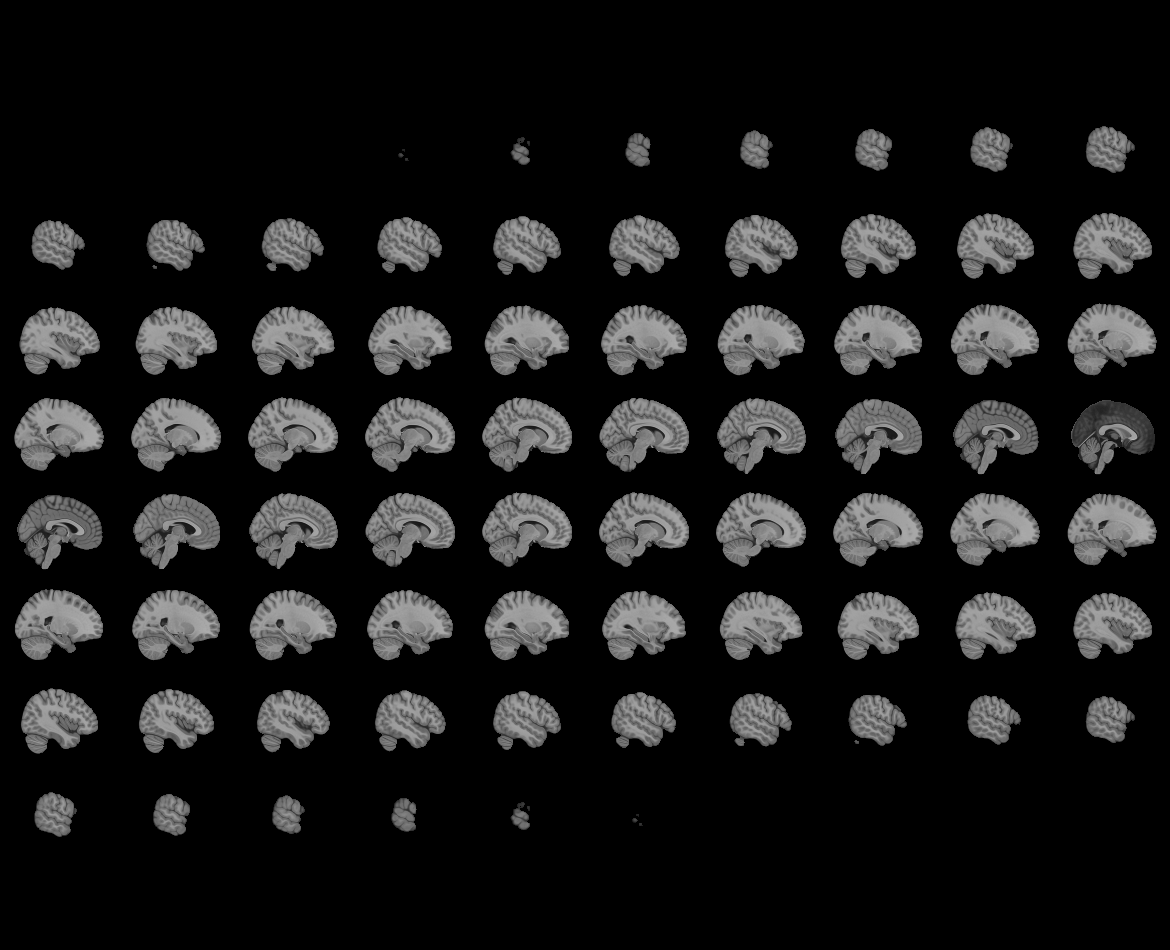
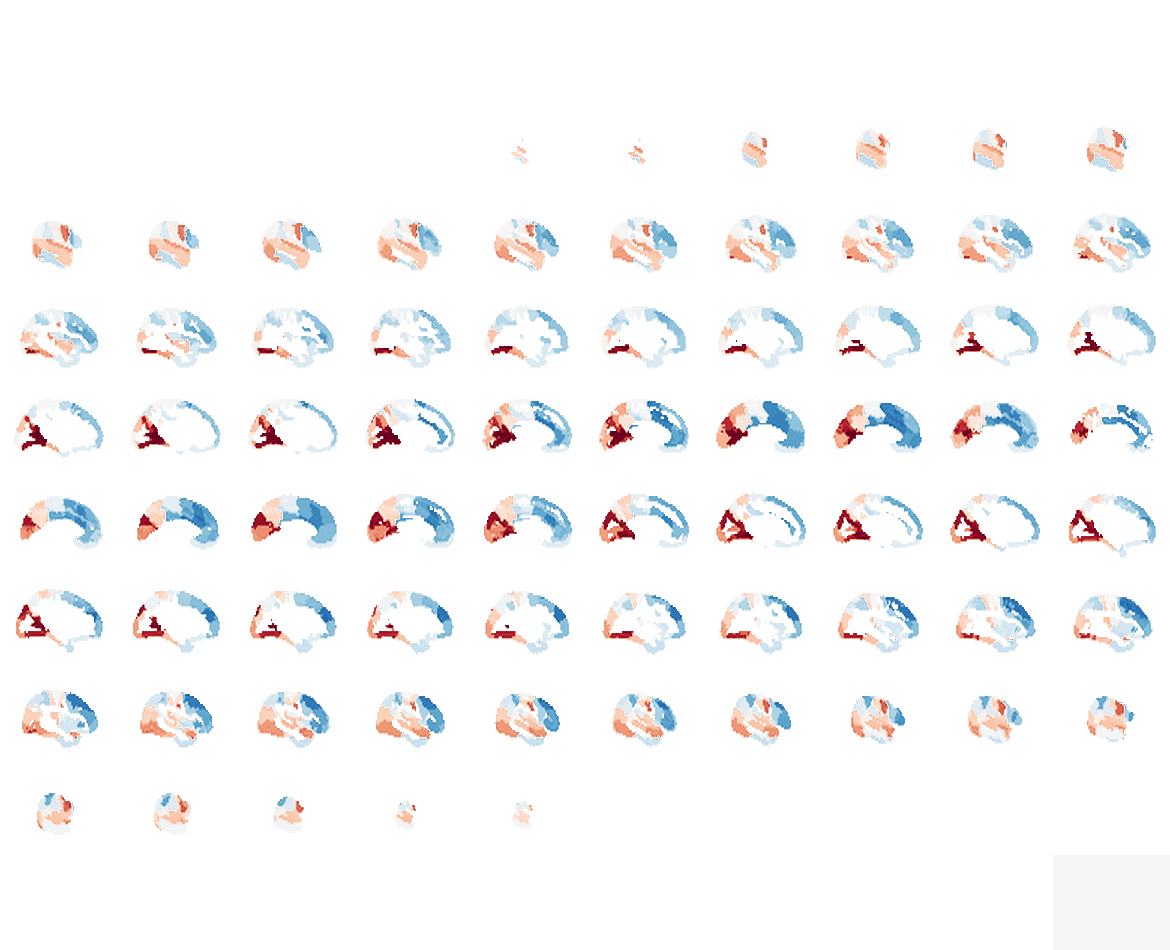

In [96]:

# out_cope[atlas.maps == idx, :].shape

from nilearn import plotting

plotting.view_img(image.mean_img(cope_img))

In [103]:
yeo_data.shape

(53, 65, 43, 1)

In [22]:
yeo = datasets.fetch_atlas_yeo_2011(n_networks=7)
yeo

[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011


{'maps': '/Users/zach/nilearn_data/yeo_2011/Yeo_JNeurophysiol11_MNI152/Yeo2011_7Networks_MNI152_FreeSurferConformed1mm_LiberalMask.nii.gz',
 'labels': ['Background',
  '7Networks_1',
  '7Networks_2',
  '7Networks_3',
  '7Networks_4',
  '7Networks_5',
  '7Networks_6',
  '7Networks_7'],
 'description': ".. _yeo_2011_atlas:\n\nYeo 2011 atlas\n==============\n\nAccess\n------\nSee :func:`nilearn.datasets.fetch_atlas_yeo_2011`.\n\nNotes\n-----\nThis atlas provides a labeling of some cortical voxels in the fsaverage.\n\nFour versions of the atlas are available,\naccording to the cortical model (thick or thin cortical surface)\nand to the number of networks considered (7 or 17).\n\nFor more information on this dataset's structure,\nsee :footcite:t:`CorticalParcellation_Yeo2011`,\nand :footcite:t:`Yeo2011`.\n\nContent\n-------\n:'anat': Background anatomical image for reference and visualization\n:'thin_7': Cortical parcelation into 7 networks, thin cortical model\n:'thin_17': Cortical parcela

In [36]:

import numpy as np
from nilearn import image, datasets

desc_add = "clean-with-fd-clamped-original-sleep-incl-nrem3-flame"

data, _ = mrio.load_FLAME_result(contrast="mreyemove_W", desc_add=desc_add)

# Load Yeo 7 atlas and resample to cope space
yeo = datasets.fetch_atlas_yeo_2011(n_networks=7)
yeo_img = yeo.maps

yeo_resampled = image.resample_to_img(yeo_img, data.t_stat, interpolation='nearest', force_resample=True, copy_header=True)
yeo_data = yeo_resampled.get_fdata()  # (X, Y, Z), values 1-7
if yeo_data.ndim == 4:
    yeo_data = yeo_data[:,:,:,0]
cope_data = data.t_stat.get_fdata()  # (X, Y, Z)
# 
# 1 - purple = visual 
# 2 - blue = somatamotor
# 3 - green = dorsal attention
# 4 - violet = vental attention
# 5 - cream = limbic 
# 6 - orange = frontoparietal 
# 7 - red = default
network_names = ['Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']

results = {}
for net_id, net_name in enumerate(network_names, start=1):
    mask = yeo_data == net_id          # (X, Y, Z) boolean
    voxels = cope_data[mask]      # (n_voxels)
    
    results[net_name] = {
        'mean_t': voxels.mean(axis=0),           # (subjects,) mean cope per subject
        'pct_positive': (voxels > 0).mean(axis=0),  # (subjects,) fraction positive voxels
    }
    

[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011


In [49]:
def network_summary(contrast, yeo_data, names):
    desc_add = "clean-with-fd-clamped-original-nrem3-incl-flame"

    data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)
    z_img     = data.z_stat
    brain_mask = data.mask 
    
    # FDR + cluster extent, computed once over the brain
    thr_map, thr = threshold_stats_img(
        data.z_stat , alpha=0.05, height_control="fdr",
        cluster_threshold=20, two_sided=True, mask_img=brain_mask,
    )
    
    z, sig = z_img.get_fdata(), thr_map.get_fdata() != 0
    out = {}
    for k, name in enumerate(names, start=1):
        m = yeo_data == k
        v, s = z[m], sig[m]
        out[name] = dict(mean_z=v.mean(), median_z=np.median(v),
                         pct_sig=100 * s.mean(),
                         pct_pos_sig=100 * (v[s] > 0).mean() if s.any() else np.nan,
                         pct_pos=100 * (v > 0).mean(),
                         )
    return out


wake_res  = network_summary("mreyemove_W",  yeo_data, network_names)
sleep_res = network_summary("mreyemove_1", yeo_data, network_names)

for net in network_names:
    w, s = wake_res[net], sleep_res[net]
    print(f"{net:12s} mean_z W={w['mean_z']:+.2f} S={s['mean_z']:+.2f} "
          f"Δ={w['mean_z']-s['mean_z']:+.2f}  %sig W={w['pct_sig']:4.1f} S={s['pct_sig']:4.1f}    %+sig W={w['pct_pos_sig']:4.1f} S={s['pct_pos_sig']:4.1f}")

Visual       mean_z W=+2.20 S=+1.84 Δ=+0.37  %sig W=42.6 S= 9.5    %+sig W=100.0 S=100.0
Somatomotor  mean_z W=+0.16 S=+0.06 Δ=+0.09  %sig W= 2.3 S= 0.0    %+sig W=43.1 S=100.0
Dorsal Attention mean_z W=+0.41 S=+0.43 Δ=-0.02  %sig W= 3.6 S= 0.8    %+sig W=93.5 S=80.8
Ventral Attention mean_z W=+0.26 S=-0.41 Δ=+0.66  %sig W= 1.8 S= 1.0    %+sig W=90.7 S= 3.2
Limbic       mean_z W=-0.30 S=+0.00 Δ=-0.31  %sig W= 0.0 S= 0.0    %+sig W= 0.0 S= nan
Frontoparietal mean_z W=-1.08 S=-1.34 Δ=+0.27  %sig W= 9.3 S= 5.6    %+sig W=18.6 S= 3.7
Default      mean_z W=-1.28 S=-0.27 Δ=-1.01  %sig W=12.0 S= 1.4    %+sig W=13.8 S=15.4


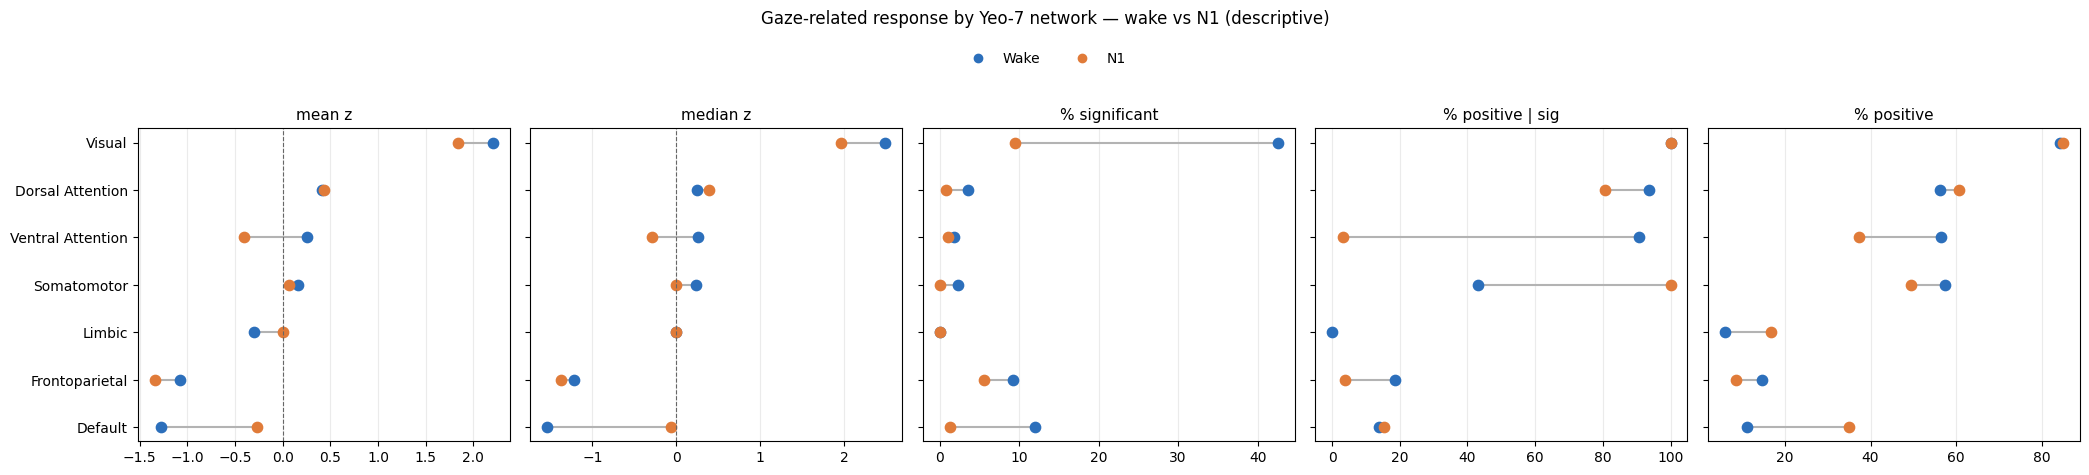

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

metrics = [('mean_z', 'mean z', True),          # signed → zero line
           ('median_z', 'median z', True),          # signed → zero line
           ('pct_sig', '% significant', False),
           ('pct_pos_sig', '% positive | sig', False),
           ('pct_pos', '% positive', False),
           ]

label_mapping = {
    
}
order = sorted(network_names, key=lambda n: wake_res[n]['mean_z'], reverse=True)
y = np.arange(len(order))[::-1]                  # strongest at top
c_w, c_s = '#2C6FBB', '#E07B39'                  # wake, sleep

fig, axes = plt.subplots(1, len(metrics), figsize=(4.2 * len(metrics), 4.2),
                         sharey=True)

for ax, (key, label, signed) in zip(axes, metrics):
    for yi, net in zip(y, order):
        w, s = wake_res[net][key], sleep_res[net][key]
        if np.isfinite(w) and np.isfinite(s):
            ax.plot([w, s], [yi, yi], color='0.7', lw=1.5, zorder=1)
        if np.isfinite(w):
            ax.scatter(w, yi, color=c_w, s=55, zorder=2)
        if np.isfinite(s):
            ax.scatter(s, yi, color=c_s, s=55, zorder=2)
    if signed:
        ax.axvline(0, color='0.4', lw=0.8, ls='--')
    ax.set_title(label, fontsize=11)
    ax.grid(axis='x', color='0.92'); ax.set_axisbelow(True)

axes[0].set_yticks(y); axes[0].set_yticklabels(order)
fig.legend(handles=[Line2D([0], [0], marker='o', ls='', color=c_w, label='Wake'),
                    Line2D([0], [0], marker='o', ls='', color=c_s, label='N1')],
           loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.suptitle('Gaze-related response by Yeo-7 network — wake vs N1 (descriptive)',
             y=1.12, fontsize=12)
fig.tight_layout()
plt.show()

In [25]:
import numpy as np
from nilearn import image, datasets
from nilearn.glm import threshold_stats_img

desc_add = "clean-with-fd-clamped-original-sleep-incl-nrem3-flame"
data, _ = mrio.load_FLAME_result(contrast="mreyemove_W", desc_add=desc_add)

z_img      = data.t_stat
brain_mask = data.mask 

# FDR + cluster extent, computed once over the brain
thr_map, thr = threshold_stats_img(
    data.z_stat , alpha=0.05, height_control="fdr",
    cluster_threshold=20, two_sided=True, mask_img=brain_mask,
)
print(f"FDR z-threshold: {thr:.3f}")

# Yeo thick_7 is (X, Y, Z, 1) -> 3D, then resample to z space
yeo = datasets.fetch_atlas_yeo_2011()
yeo_img = image.load_img(yeo.thick_7)
if yeo_img.ndim == 4:
    yeo_img = image.index_img(yeo_img, 0)
yeo_img = image.resample_to_img(
    yeo_img, z_img, interpolation="nearest",
    force_resample=True, copy_header=True,
)

yeo_data = yeo_img.get_fdata()        # (X, Y, Z)
z        = z_img.get_fdata()          # (X, Y, Z)
sig      = thr_map.get_fdata() != 0   # survived FDR + cluster extent (two-sided)

network_names = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn',
                 'Limbic', 'Control', 'Default']

results = {}
for net_id, net_name in enumerate(network_names, start=1):
    mask = yeo_data == net_id
    v, s = z[mask], sig[mask]
    n, n_sig = v.size, int(s.sum())
    if n == 0:
        continue
    results[net_name] = {
        'n_voxels':    n,
        'mean_z':      v.mean(),
        'median_z':    float(np.median(v)),
        'iqr_z':       float(np.subtract(*np.percentile(v, [75, 25]))),
        'pct_sig':     100 * n_sig / n,                       # FDR + cluster
        'pct_pos_sig': 100 * (v[s] > 0).mean() if n_sig else np.nan,
        'pct_neg_sig': 100 * (v[s] < 0).mean() if n_sig else np.nan,
    }

FDR z-threshold: 2.724
[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_51489/1891550362.py:19: DeprecationWarning: From release >=0.13.0, instead of returning several atlas image accessible via different keys, this fetcher will return the atlas as a dictionary with a single atlas image, accessible through a 'maps' key. To suppress this warning, Please use the parameters 'n_networks' and 'thickness' to specify the exact atlas image you want.
  yeo = datasets.fetch_atlas_yeo_2011()


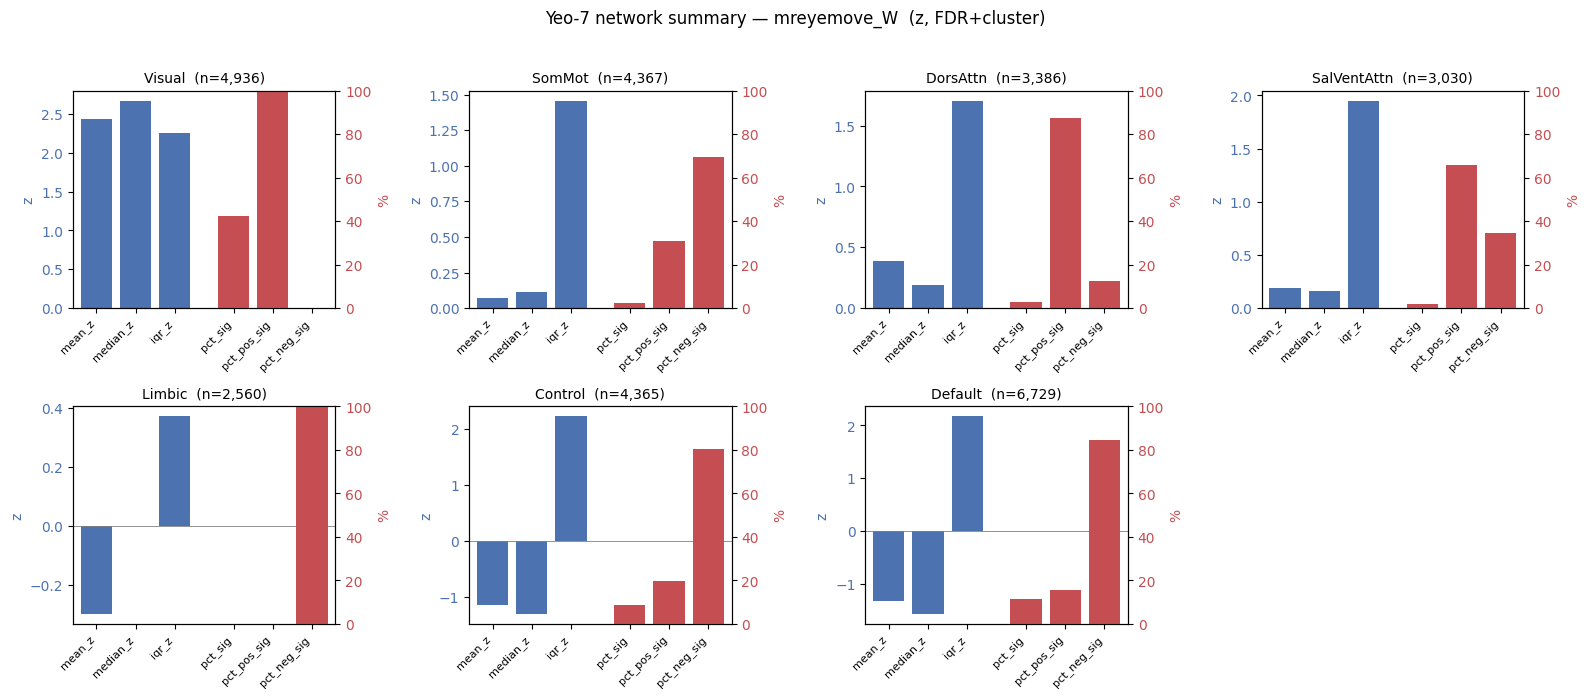

In [11]:
import numpy as np
import matplotlib.pyplot as plt

z_keys   = ['mean_z', 'median_z', 'iqr_z']
pct_keys = ['pct_sig', 'pct_pos_sig', 'pct_neg_sig']
labels   = z_keys + pct_keys

networks = list(results.keys())
ncols    = 4
nrows    = int(np.ceil(len(networks) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.4 * nrows))
axes = axes.ravel()

x_z   = np.arange(len(z_keys))                          # 0, 1, 2
x_pct = np.arange(len(pct_keys)) + len(z_keys) + 0.5    # 3.5, 4.5, 5.5
c_z, c_pct = '#4C72B0', '#C44E52'

for i, net in enumerate(networks):
    ax, r = axes[i], results[net]

    ax.bar(x_z, [r[k] for k in z_keys], color=c_z, width=0.8)
    ax.axhline(0, color='gray', lw=0.6)
    ax.set_ylabel('z', color=c_z); ax.tick_params(axis='y', labelcolor=c_z)

    ax2 = ax.twinx()
    ax2.bar(x_pct, [r[k] for k in pct_keys], color=c_pct, width=0.8)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('%', color=c_pct); ax2.tick_params(axis='y', labelcolor=c_pct)

    ax.set_xlim(-0.6, 6.1)
    ax.set_xticks(np.concatenate([x_z, x_pct]))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"{net}  (n={r['n_voxels']:,})", fontsize=10)

for j in range(len(networks), len(axes)):
    axes[j].axis('off')

fig.suptitle("Yeo-7 network summary — mreyemove_W  (z, FDR+cluster)", y=1.02)
fig.tight_layout()
plt.show()

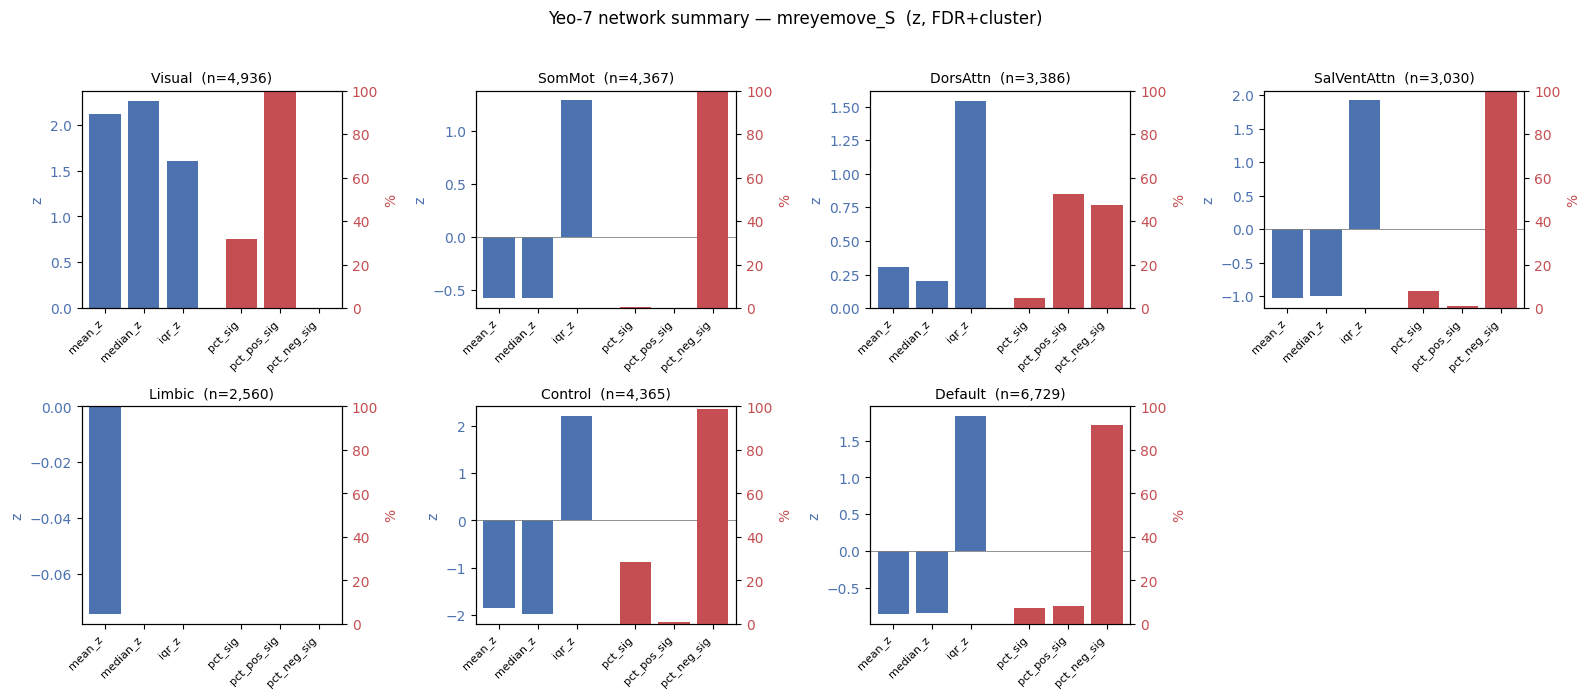

In [6]:
import numpy as np
import matplotlib.pyplot as plt

z_keys   = ['mean_z', 'median_z', 'iqr_z']
pct_keys = ['pct_sig', 'pct_pos_sig', 'pct_neg_sig']
labels   = z_keys + pct_keys

networks = list(results.keys())
ncols    = 4
nrows    = int(np.ceil(len(networks) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.4 * nrows))
axes = axes.ravel()

x_z   = np.arange(len(z_keys))                          # 0, 1, 2
x_pct = np.arange(len(pct_keys)) + len(z_keys) + 0.5    # 3.5, 4.5, 5.5
c_z, c_pct = '#4C72B0', '#C44E52'

for i, net in enumerate(networks):
    ax, r = axes[i], results[net]

    ax.bar(x_z, [r[k] for k in z_keys], color=c_z, width=0.8)
    ax.axhline(0, color='gray', lw=0.6)
    ax.set_ylabel('z', color=c_z); ax.tick_params(axis='y', labelcolor=c_z)

    ax2 = ax.twinx()
    ax2.bar(x_pct, [r[k] for k in pct_keys], color=c_pct, width=0.8)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('%', color=c_pct); ax2.tick_params(axis='y', labelcolor=c_pct)

    ax.set_xlim(-0.6, 6.1)
    ax.set_xticks(np.concatenate([x_z, x_pct]))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"{net}  (n={r['n_voxels']:,})", fontsize=10)

for j in range(len(networks), len(axes)):
    axes[j].axis('off')

fig.suptitle("Yeo-7 network summary — mreyemove_S  (z, FDR+cluster)", y=1.02)
fig.tight_layout()
plt.show()